In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the uploaded csv file

In [2]:
pd.options.display.max_rows = 9999
data = pd.read_csv("customer_segmentation_data.csv")
data

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53498,44809,35,Female,Divorced,Associate Degree,Andaman and Nicobar Islands,Salesperson,120850,policy3,01-01-2019,Mobile App,policy1,586401,4404,Family,In-Person Meeting,Phone,Afternoon,German,Segment5
53499,65485,61,Male,Single,Doctorate,Himachal Pradesh,Entrepreneur,122309,policy5,5/18/2021,Mobile App,policy4,637733,1285,Group,Text,Mail,Afternoon,German,Segment1
53500,26213,25,Male,Divorced,Doctorate,Assam,Teacher,49258,policy2,11/27/2018,In-Person,policy1,631057,4407,Individual,Text,Text,Weekends,French,Segment4
53501,63136,42,Male,Married,Doctorate,Andhra Pradesh,Artist,66301,policy4,06-04-2021,In-Person,policy1,730385,4482,Business,Mail,Phone,Morning,French,Segment5


In [4]:
print(pd.options.display.max_rows)


9999


In [90]:
data

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,...,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Age Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,...,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5,1
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,...,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5,1
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,...,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3,1
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,...,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3,1
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,...,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53498,44809,35,Female,Divorced,Associate Degree,Andaman and Nicobar Islands,Salesperson,120850,policy3,01-01-2019,...,policy1,586401,4404,Family,In-Person Meeting,Phone,Afternoon,German,Segment5,2
53499,65485,61,Male,Single,Doctorate,Himachal Pradesh,Entrepreneur,122309,policy5,5/18/2021,...,policy4,637733,1285,Group,Text,Mail,Afternoon,German,Segment1,5
53500,26213,25,Male,Divorced,Doctorate,Assam,Teacher,49258,policy2,11/27/2018,...,policy1,631057,4407,Individual,Text,Text,Weekends,French,Segment4,1
53501,63136,42,Male,Married,Doctorate,Andhra Pradesh,Artist,66301,policy4,06-04-2021,...,policy1,730385,4482,Business,Mail,Phone,Morning,French,Segment5,3


In [5]:
def assign_age_group(age):
    if 18 <= age <= 30:
        return "18-30"
    elif 31 <= age <= 40:
        return "31-40"
    elif 41 <= age <= 50:
        return "41-50"
    elif 51 <= age <= 60:
        return "51-60"
    else:
        return "61+"

data["Age Group"] = data["Age"].apply(assign_age_group)

age_group_mapping = {"18-30": 1, "31-40": 2, "41-50": 3, "51-60": 4, "61+": 5}
data["Age Group"] = data["Age Group"].map(age_group_mapping)

# Display the first few rows and summary info to understand the structure of the dataset

In [6]:
data.head() # Returns first 5 row

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,...,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Age Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,...,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5,1
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,...,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5,1
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,...,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3,1
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,...,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3,1
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,...,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2,1


In [92]:
data.info() # is a DataFrame method used to Quickly view the structure of your dataset. it provides essential information about the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

In [93]:
data.duplicated().sum()

0

In [94]:
from sklearn.preprocessing import LabelEncoder

In [95]:
# Separate Categorical and numerical columns
Categorical_columns = data.select_dtypes(include=["object"]).columns
numerical_columns = data.select_dtypes(include=["number"]).columns

In [96]:
# Label Encode Categorical columns fro simplicity
label_encoder = LabelEncoder()
for col in Categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

In [97]:
data.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,...,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Age Group
0,84966,23,0,1,0,22,3,70541,4,270,...,1,366603,2749,2,0,1,0,0,4,1
1,95568,26,1,4,2,10,5,54168,4,942,...,0,780236,1966,2,2,1,3,1,4,1
2,10544,29,0,3,0,27,3,73899,4,387,...,2,773926,4413,2,0,2,2,2,2,1
3,77033,20,1,0,1,28,3,63381,4,582,...,1,787815,4342,1,4,1,1,1,2,1
4,88160,25,0,2,1,34,5,38794,0,630,...,3,366506,1276,1,0,4,4,0,1,1


In [57]:
data.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,0,1,0,22,3,70541,4,270,4,1,366603,2749,2,0,1,0,0,4
1,95568,26,1,4,2,10,5,54168,4,942,0,0,780236,1966,2,2,1,3,1,4
2,10544,29,0,3,0,27,3,73899,4,387,1,2,773926,4413,2,0,2,2,2,2
3,77033,20,1,0,1,28,3,63381,4,582,0,1,787815,4342,1,4,1,1,1,2
4,88160,25,0,2,1,34,5,38794,0,630,0,3,366506,1276,1,0,4,4,0,1


In [58]:
def assign_age_group(age):
    if 18 <= age <= 30:
        return "18-30"
    elif 31 <= age <= 40:
        return "31-40"
    elif 41 <= age <= 50:
        return "41-50"
    elif 51 <= age <= 60:
        return "51-60"
    else:
        return "61+"

In [59]:
data['Age Group'] = data['Age'].apply(assign_age_group)

In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

In [62]:
# Encode 'Age Group' Into numerical Labelsa
age_group_mapping = {"18-30":1,"31-40":2,"41-50":3,"51-60" :4,"61+":5}
data['Age'] = data['Age'].map(age_group_mapping)

In [100]:
data

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,...,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Age Group
0,84966,23,0,1,0,22,3,70541,4,270,...,1,366603,2749,2,0,1,0,0,4,1
1,95568,26,1,4,2,10,5,54168,4,942,...,0,780236,1966,2,2,1,3,1,4,1
2,10544,29,0,3,0,27,3,73899,4,387,...,2,773926,4413,2,0,2,2,2,2,1
3,77033,20,1,0,1,28,3,63381,4,582,...,1,787815,4342,1,4,1,1,1,2,1
4,88160,25,0,2,1,34,5,38794,0,630,...,3,366506,1276,1,0,4,4,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53498,44809,35,0,0,0,0,7,120850,2,1,...,0,586401,4404,1,1,3,0,2,4,2
53499,65485,61,1,3,2,13,3,122309,4,1569,...,3,637733,1285,2,4,2,0,2,0,5
53500,26213,25,1,0,2,3,8,49258,1,1068,...,0,631057,4407,3,4,4,4,1,3,1
53501,63136,42,1,1,2,1,0,66301,3,381,...,0,730385,4482,0,2,3,3,1,4,3


In [23]:
# set plot style
sns.set_theme(style="whitegrid")

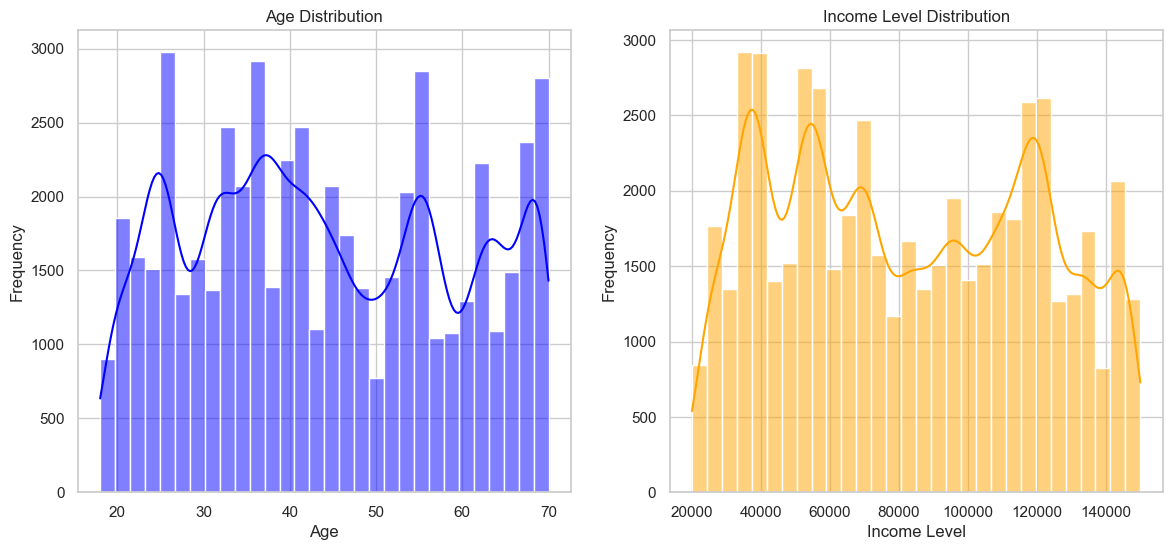

In [73]:
# plot distributions for numerical columns: Age and income level.
fig, axes = plt.subplots(1,2, figsize=(14,6))

# Age Distribution
sns.histplot(data['Age'],bins=30, kde= True, ax=axes[0],color="blue")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Income Level distribution
sns.histplot(data['Income Level'],bins=30, kde= True, ax=axes[1],color="orange")
axes[1].set_title("Income Level Distribution")
axes[1].set_xlabel("Income Level")
axes[1].set_ylabel("Frequency")

plt.show()


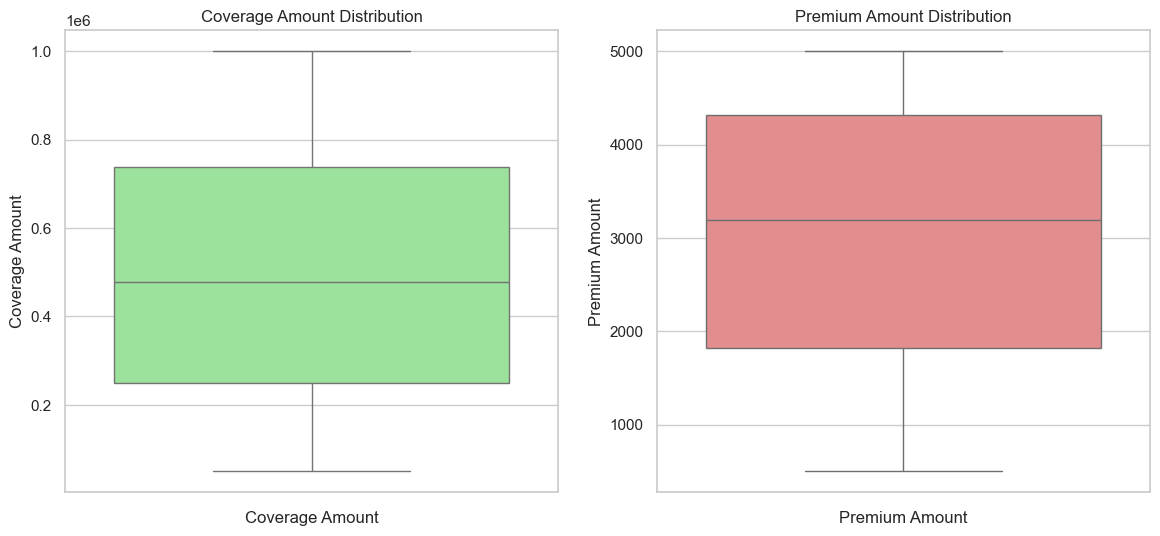

In [75]:
# Coverage Amount distribution
# Plot distributions for Coverage Amount and Premium Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data['Coverage Amount'], ax=axes[0], color="lightgreen")
axes[0].set_title("Coverage Amount Distribution")
axes[0].set_xlabel("Coverage Amount")

# Premium Amount distribution
sns.boxplot(data['Premium Amount'], ax=axes[1], color="lightcoral")
axes[1].set_title("Premium Amount Distribution")
axes[1].set_xlabel("Premium Amount")

plt.show()

In [78]:
# Select relevant numerical columns for correlation analysis
numerical_columns = ['Age','Income Level','Premium Amount']
# Compute the correlation matrix
correlation_matrix = data[numerical_columns].corr()

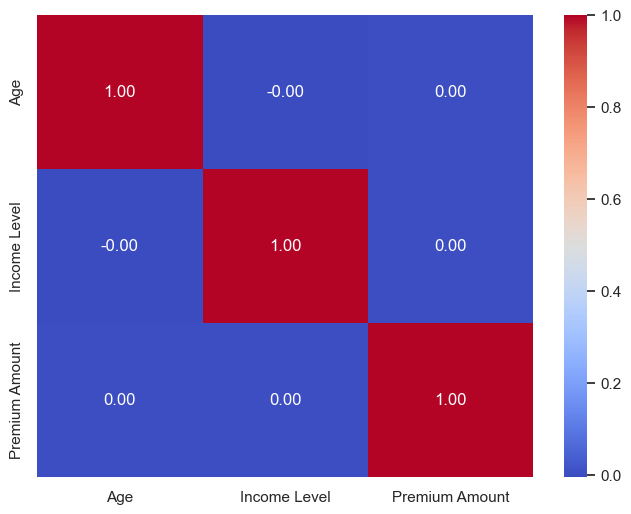

In [80]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True,cmap="coolwarm",fmt=".2f",cbar=True)
plt.show()
# annot=True: shows the correlation values inside the squares.
# cmap="coolwarm": color palette from red (1) to blue (-1).
# fmt=".2f": formats numbers to two decimal places.
# cbar=True: adds the color bar on the right.

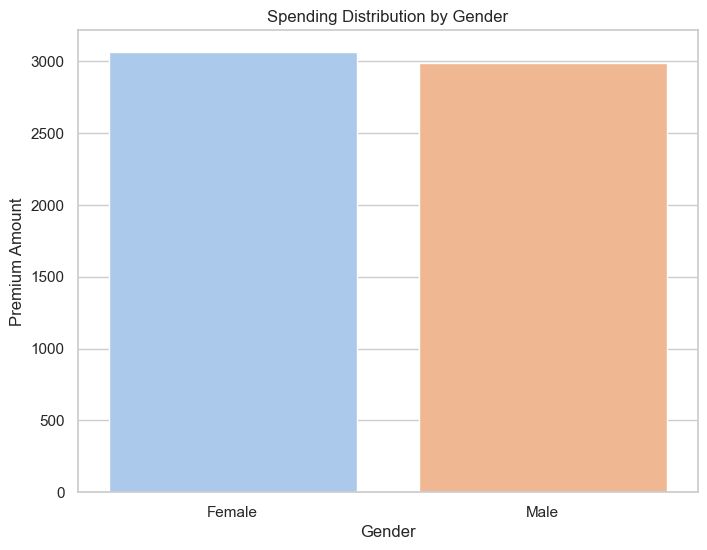

In [85]:
# Bar chart for gender vs. spending
plt.figure(figsize=(8,6))
sns.barplot(data=data,x='Gender', y='Premium Amount', errorbar=None, palette="pastel",hue='Gender',legend=False)
plt.title("Spending Distribution by Gender")
plt.ylabel("Premium Amount")
plt.xlabel("Gender")
plt.show()

C:\Users\Johnnie Daniel\AppData\Local\Temp\ipykernel_17016\3245630269.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x='Marital Status', y='Premium Amount', ci=None, palette="Blues")
C:\Users\Johnnie Daniel\AppData\Local\Temp\ipykernel_17016\3245630269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Marital Status', y='Premium Amount', ci=None, palette="Blues")


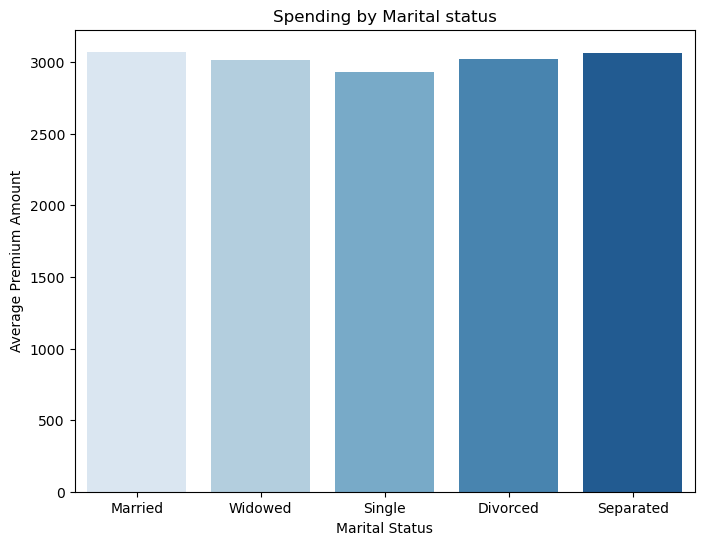

In [7]:
# Group by marital status and visualize spending
plt.figure(figsize=(8,6))
sns.barplot(data=data, x='Marital Status', y='Premium Amount', ci=None, palette="Blues")
plt.title("Spending by Marital status")
plt.ylabel("Average Premium Amount")
plt.xlabel("Marital Status")
plt.show()

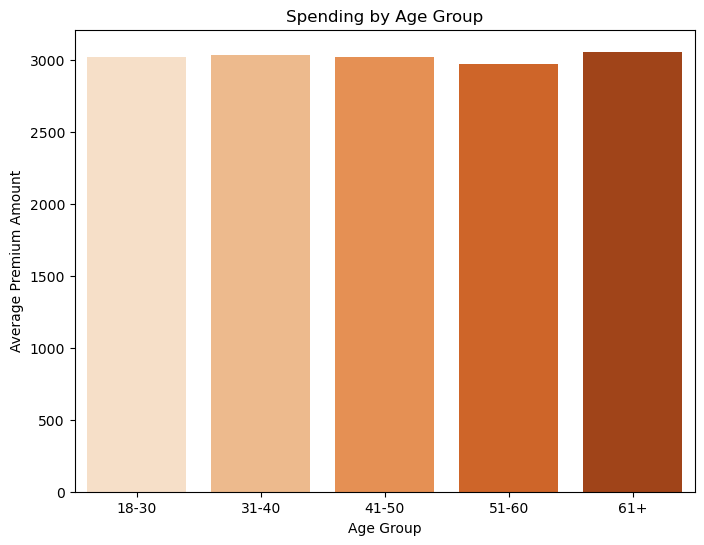

In [9]:
# Group by age ranges and visualize spending
data['Age Group'] = pd.cut(data['Age'], bins=[18, 30, 40, 50, 60, 80],
                                   labels=["18-30", "31-40", "41-50", "51-60", "61+"])

plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='Age Group', y='Premium Amount', errorbar=None, hue='Age Group', palette='Oranges', legend=False)

plt.title("Spending by Age Group")
plt.ylabel("Average Premium Amount")
plt.xlabel("Age Group")
plt.show()
